# **Homework 1- Visualization**
### BUDT704- Data Processing and Analysis in Python-Fall 2024 maseri

Shruti Elango
(selango4)

In [ ]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
worlddata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/BUDT704- Data Processing and Analysis in Python-Fall 2024 maseri/Large Data Sets for Python/worlddata.csv')
worlddata.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
0,Arab World,ARB,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960,1.335609e+02
1,Arab World,ARB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960,8.779760e+01
2,Arab World,ARB,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,1960,6.634579e+00
3,Arab World,ARB,"Age dependency ratio, young (% of working-age ...",SP.POP.DPND.YG,1960,8.102333e+01
4,Arab World,ARB,Arms exports (SIPRI trend indicator values),MS.MIL.XPRT.KD,1960,3.000000e+06


In [ ]:
Indicator_Values = worlddata.IndicatorName.unique()
Indicator_Values

array(['Adolescent fertility rate (births per 1,000 women ages 15-19)',
       'Age dependency ratio (% of working-age population)',
       'Age dependency ratio, old (% of working-age population)', ...,
       'Fish species, threatened', 'Mammal species, threatened',
       'Plant species (higher), threatened'], dtype=object)

In [ ]:
indicator_counts = worlddata['IndicatorName'].value_counts().head(60)
print(indicator_counts)

IndicatorName
Population, total                                                                          13484
Population growth (annual %)                                                               13442
Rural population (% of total population)                                                   13415
Urban population (% of total)                                                              13415
Urban population                                                                           13374
Rural population                                                                           13374
Urban population growth (annual %)                                                         13337
Surface area (sq. km)                                                                      13090
Land area (sq. km)                                                                         13086
Rural population growth (annual %)                                                         13061
Population densi

### **How do environmental indicators like CO2 emissions or land use and urbanization affect population growth**
Key Variables:
* Permanent cropland (% of land area)
* CO2 emissions (kt)
* Food production index (2004-2006 = 100)
* Surface area (sq. km)
* Arable land (% of land area)
* Crop production index
* Population growth (annual %)
* Urban population (% of total)  
* Rural population (% of total population)
* Population, total



In [ ]:
required_variables = ['Permanent cropland (% of land area)','CO2 emissions (kt)', 'Food production index (2004-2006 = 100)','Surface area (sq. km)',
'Arable land (% of land area)', 'Crop production index (2004-2006 = 100)', 'Population growth (annual %)', 'Urban population (% of total)', 'Rural population (% of total population)',
'Population, total', "Country Name"]
wd_E5 = worlddata[worlddata["IndicatorName"].isin(required_variables)]
wd_E5

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
7,Arab World,ARB,CO2 emissions (kt),EN.ATM.CO2E.KT,1960,5.956399e+04
73,Arab World,ARB,"Population, total",SP.POP.TOTL,1960,9.249590e+07
75,Arab World,ARB,Rural population (% of total population),SP.RUR.TOTL.ZS,1960,6.871462e+01
79,Arab World,ARB,Urban population (% of total),SP.URB.TOTL.IN.ZS,1960,3.128538e+01
85,Caribbean small states,CSS,CO2 emissions (kt),EN.ATM.CO2E.KT,1960,5.878201e+03
...,...,...,...,...,...,...
5641516,Zimbabwe,ZWE,Population growth (annual %),SP.POP.GROW,2014,2.307451e+00
5641524,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2014,1.524586e+07
5641641,Zimbabwe,ZWE,Rural population (% of total population),SP.RUR.TOTL.ZS,2014,6.749900e+01
5641656,Zimbabwe,ZWE,Surface area (sq. km),AG.SRF.TOTL.K2,2014,3.907600e+05


### Creating a new, organized dataset

In [ ]:
wd_pivot=pd.pivot_table(wd_E5, values='Value', index=['CountryName','CountryCode', 'Year'], columns=['IndicatorName'])
wd_pivot.rename(columns={'Permanent cropland (% of land area)':'Crop Land (% of area)','CO2 emissions (kt)':'CO2 Emissions (kt)', 'Food production index (2004-2006 = 100)': 'Food Production','Surface area (sq. km)': 'Land area (sq. km)',
'Arable land (% of land area)': 'Arable Land (% of land)', 'Crop production index (2004-2006 = 100)':'Crop production index', 'Population growth (annual %)': 'Population growth (annual %)', 'Urban population (% of total)':'Urban population (% of total)',
                        'Rural population (% of total population)':'Rural population (% of total)',
'Population, total': 'Population'}, inplace=True)

wd_pivot.reset_index(inplace=True)
wd_pivot

IndicatorName,CountryName,CountryCode,Year,Arable Land (% of land),CO2 Emissions (kt),Crop production index,Food Production,Crop Land (% of area),Population growth (annual %),Population,Rural population (% of total),Land area (sq. km),Urban population (% of total)
0,Afghanistan,AFG,1960,NaN,414.371,NaN,NaN,NaN,1.813677,8994793.0,91.779,NaN,8.221
1,Afghanistan,AFG,1961,11.717673,491.378,67.38,54.02,0.076586,1.874003,9164945.0,91.492,652860.0,8.508
2,Afghanistan,AFG,1962,11.794259,689.396,68.90,54.68,0.091903,1.932414,9343772.0,91.195,652860.0,8.805
3,Afghanistan,AFG,1963,11.870845,707.731,67.26,54.65,0.091903,1.989785,9531555.0,90.890,652860.0,9.110
4,Afghanistan,AFG,1964,11.947431,839.743,73.15,59.12,0.111816,2.046675,9728645.0,90.574,652860.0,9.426
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13578,Zimbabwe,ZWE,2010,10.339925,9028.154,99.55,96.05,0.258498,1.826380,13973897.0,66.804,390760.0,33.196
13579,Zimbabwe,ZWE,2011,10.856921,9860.563,105.67,100.19,0.258498,1.995816,14255592.0,66.985,390760.0,33.015
13580,Zimbabwe,ZWE,2012,10.339925,NaN,106.53,99.78,0.258498,2.150523,14565482.0,67.166,390760.0,32.834
13581,Zimbabwe,ZWE,2013,10.339925,NaN,108.19,97.96,0.258498,2.257867,14898092.0,67.346,390760.0,32.654


### Filter all Non-Countries out and remove all Nan values from the dataset to make it more clean.

In [ ]:
non_countries = [
    'Arab World', 'Caribbean small states', 'Central Europe and the Baltics',
    'East Asia & Pacific (all income levels)', 'East Asia & Pacific (developing only)',
    'Euro area', 'Europe & Central Asia (all income levels)',
    'Europe & Central Asia (developing only)', 'European Union',
    'Fragile and conflict affected situations', 'Heavily indebted poor countries (HIPC)',
    'High income', 'High income: OECD', 'High income: nonOECD',
    'Latin America & Caribbean (all income levels)',
    'Latin America & Caribbean (developing only)', 'Least developed countries: UN classification',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle East & North Africa (all income levels)',
    'Middle East & North Africa (developing only)', 'Middle income',
    'North America', 'OECD members', 'Other small states',
    'Pacific island small states', 'Small states', 'South Asia',
    'Sub-Saharan Africa (all income levels)', 'Sub-Saharan Africa (developing only)',
    'Upper middle income', 'World'
]

df_filtered = wd_pivot[~wd_pivot['CountryName'].isin(non_countries)]

df = df_filtered.dropna(subset=['Crop Land (% of area)','CO2 Emissions (kt)',  'Food Production', 'Land area (sq. km)',
 'Arable Land (% of land)','CountryName','CountryCode', 'Year','Crop production index',  'Population growth (annual %)','Population','Urban population (% of total)', 'Rural population (% of total)'])
columns_to_convert = [
    'Year', 'Arable Land (% of land)', 'CO2 Emissions (kt)', 'Crop production index',
    'Food Production', 'Crop Land (% of area)', 'Population growth (annual %)',
    'Population', 'Rural population (% of total)', 'Land area (sq. km)',
    'Urban population (% of total)'
]

df[columns_to_convert] = df[columns_to_convert].apply(pd.to_numeric, errors='coerce')

df

<ipython-input-35-511d911c52e0>:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



IndicatorName,CountryName,CountryCode,Year,Arable Land (% of land),CO2 Emissions (kt),Crop production index,Food Production,Crop Land (% of area),Population growth (annual %),Population,Rural population (% of total),Land area (sq. km),Urban population (% of total)
1,Afghanistan,AFG,1961,11.717673,491.378,67.38,54.02,0.076586,1.874003,9164945.0,91.492,652860.0,8.508
2,Afghanistan,AFG,1962,11.794259,689.396,68.90,54.68,0.091903,1.932414,9343772.0,91.195,652860.0,8.805
3,Afghanistan,AFG,1963,11.870845,707.731,67.26,54.65,0.091903,1.989785,9531555.0,90.890,652860.0,9.110
4,Afghanistan,AFG,1964,11.947431,839.743,73.15,59.12,0.111816,2.046675,9728645.0,90.574,652860.0,9.426
5,Afghanistan,AFG,1965,11.947431,1008.425,75.72,61.96,0.114879,2.102528,9935358.0,90.250,652860.0,9.750
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Zimbabwe,ZWE,2007,10.339925,9732.218,94.33,96.64,0.258498,1.285552,13297798.0,66.257,390760.0,33.743
13576,Zimbabwe,ZWE,2008,10.986170,7682.365,88.28,88.79,0.258498,1.475502,13495462.0,66.440,390760.0,33.560
13577,Zimbabwe,ZWE,2009,10.598423,8239.749,82.48,89.44,0.258498,1.657381,13720997.0,66.622,390760.0,33.378
13578,Zimbabwe,ZWE,2010,10.339925,9028.154,99.55,96.05,0.258498,1.826380,13973897.0,66.804,390760.0,33.196


## **Narrative**
* How do environmental indicators like CO2 emissions or land use and urbanization affect population growth?

* Key environmental indicators, such as CO2 emissions, land use, and urbanization, play a crucial role in shaping how populations grow and evolve over time.
* Understand the interconnectedness and how the variables evolve over time.
* Analyze the relationship between time and CO2 emissions, population, and urban population

# Population Growth

Above or Below Average Population Growth over different Countries

In [ ]:
import folium

In [ ]:
url = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data'
state_geo = f'{url}/us-states.json' # for US map with state boundaries
world_geo = f'{url}/world-countries.json' # for world map with country boundaries
state_unemployment = f'{url}/US_Unemployment_Oct2012.csv'

In [ ]:
import plotly.express as px
average_ = df['Population'].mean()

df['Population'] = ['Above Average' if value > average_ else 'Below Average' for value in df['Population']]

fig = px.choropleth(
    df,
    geojson=world_geo,
    locations='CountryCode',
    color='Population',
    color_discrete_map={'Above Average': 'blue', 'Below Average': 'yellow'},
    labels={'Population': 'Population'},
    hover_data=['Population']
)

fig.update_layout(
    updatemenus=[dict(
        buttons=list([
            dict(
                args=[{"visible": [True, True]}],
                label="All",
            ),
            dict(
                args=[{"visible": [True, False]}],
                label="Above Average",
            ),
            dict(
                args=[{"visible": [False, True]}],
                label="Below Average",
            )
        ])
    )]
)

fig.show()


<ipython-input-36-4a4f38aaf55a>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Compare year 1961 and 2011 (the minimum and maximum year values) in terms of how their Population growth (annual %) is spread via a boxplot

1961
2011


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning:

SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.



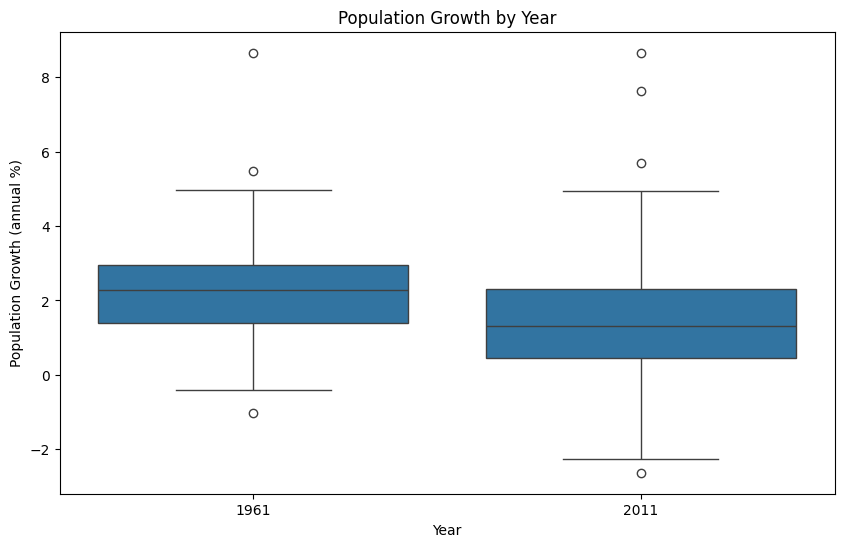

In [ ]:
min_year = df['Year'].min()
max_year = df['Year'].max()

print(min_year)
print(max_year)

df_filtered1 = df[df['Year'].isin([1961, 2011])]

plt.figure(figsize=(10, 6))
sns.boxplot(x='Year', y='Population growth (annual %)', data=df_filtered1)
plt.title('Population Growth by Year')
plt.xlabel('Year')
plt.ylabel('Population Growth (annual %)')
plt.show()


# CO2 Emissions over Time

A visual bar graph representation of how CO2 Emissions (kt) have increased throughout the years from 1961 to 2011.

In [ ]:
fig = px.bar(df, x="Year", y="CO2 Emissions (kt)")
fig.show()

 Track and compare global CO2 emissions trends at the country level dynamically.

In [ ]:
import plotly.express as px


fig = px.bar(df, x="CountryCode", y="CO2 Emissions (kt)", color="CountryCode",
  animation_frame="Year", animation_group="CountryCode", hover_name="CountryCode", range_y=[0,10000000])
fig.show()

A more in depth graph that illustrates how CO2 emissions vary over time across different countries.

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` 

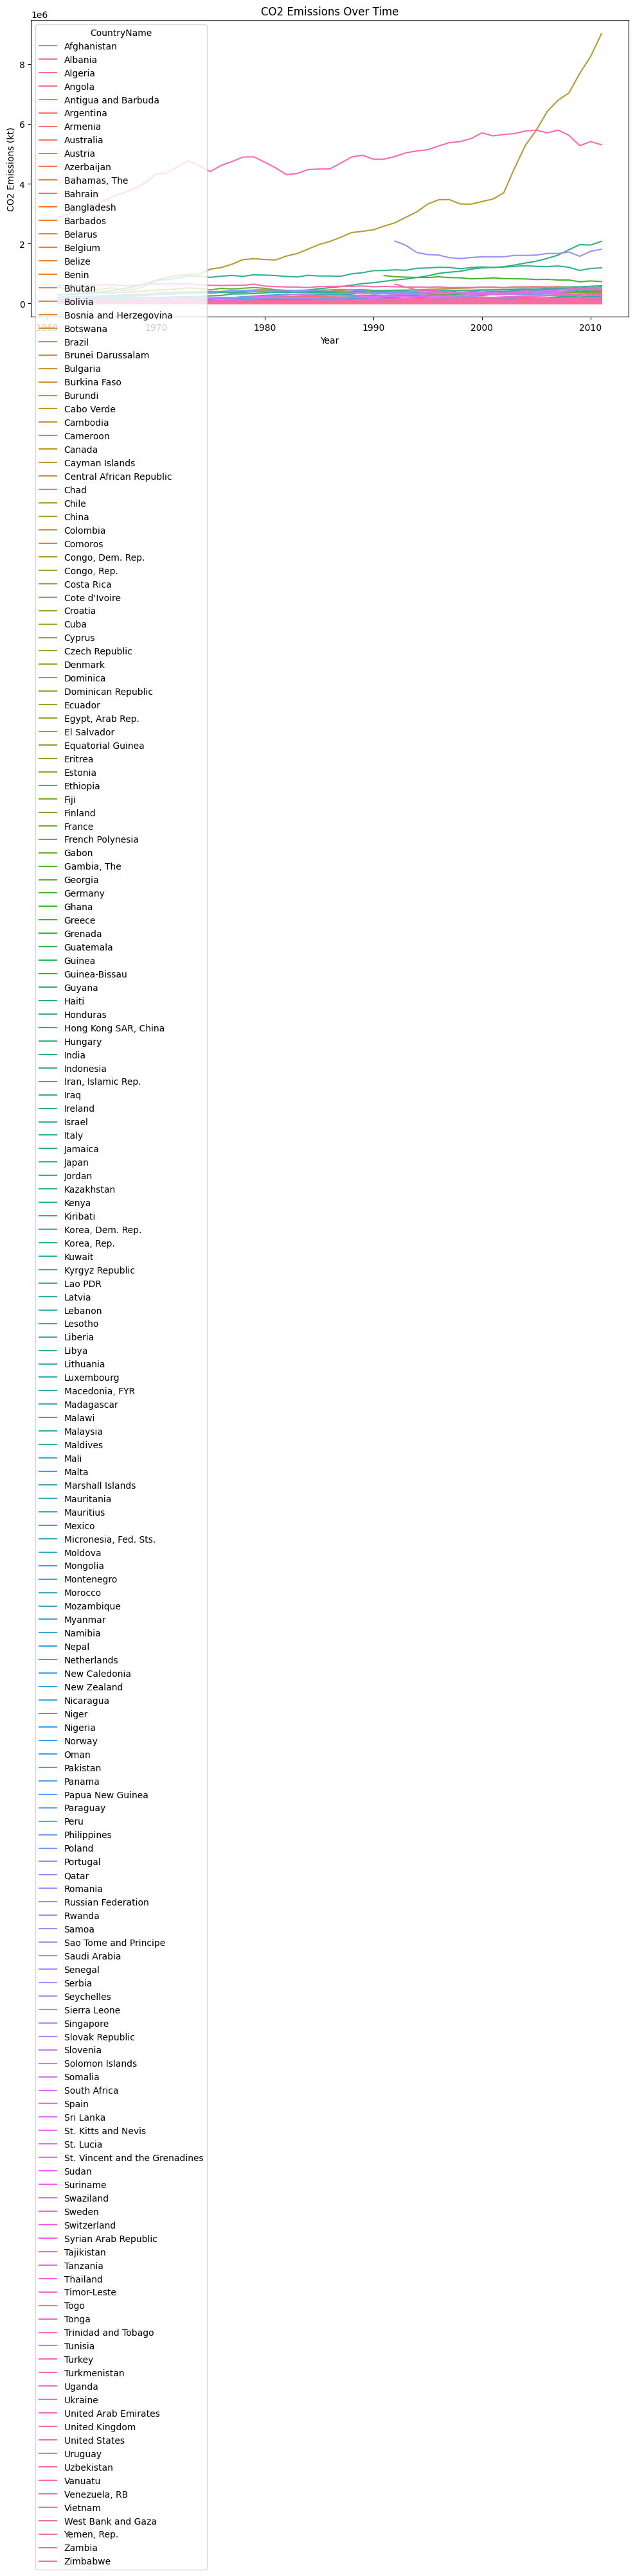

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='CO2 Emissions (kt)', hue='CountryName', data=df)
plt.title('CO2 Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (kt)')
plt.show()


Above or Below Average CO2 Emissions over different Countries

In [ ]:
import plotly.express as px
average_ = df['CO2 Emissions (kt)'].mean()

df['CO2 Emissions Category'] = ['Above Average' if value > average_ else 'Below Average' for value in df['CO2 Emissions (kt)']]

fig = px.choropleth(
    df,
    geojson=world_geo,
    locations='CountryCode',
    color='CO2 Emissions Category',
    color_discrete_map={'Above Average': 'green', 'Below Average': 'red'},
    labels={'CO2 Emissions Category': 'CO2 Emissions Category'},
    hover_data=['CO2 Emissions (kt)']
)

fig.update_layout(
    updatemenus=[dict(
        buttons=list([
            dict(
                args=[{"visible": [True, True]}],
                label="All",
            ),
            dict(
                args=[{"visible": [True, False]}],
                label="Above Average",
            ),
            dict(
                args=[{"visible": [False, True]}],
                label="Below Average",
            )
        ])
    )]
)

fig.show()


<ipython-input-41-b0a857c3d93b>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Choropleth, color map of CO2 Emissions (kt) of the World

In [ ]:
import plotly.express as px

fig = px.choropleth(
    df,
    geojson=world_geo,
    locations='CountryCode',
    color='CO2 Emissions (kt)',
    color_continuous_scale="Viridis",
    range_color=(df['CO2 Emissions (kt)'].min(), df['CO2 Emissions (kt)'].max()),
    labels={'CO2 Emissions (kt)': 'CO2 Emissions (kt)'}
)

fig.show()

CO2 Emissions (kt) trends as time goes by in reflection to Rural population (% of total)

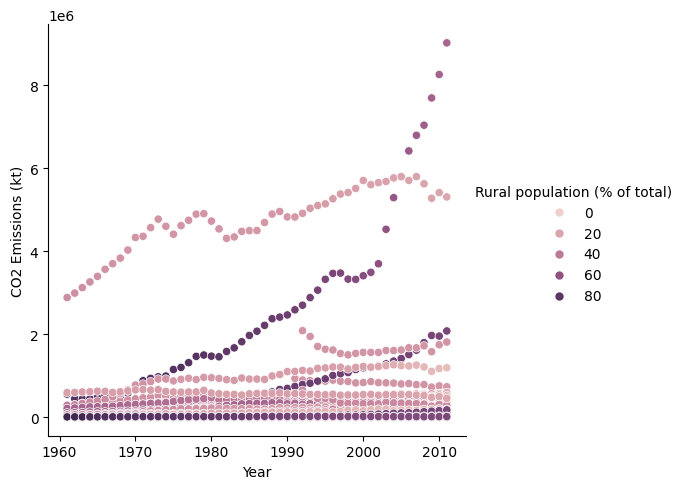

In [ ]:
sns.relplot(x="Year", y="CO2 Emissions (kt)", hue="Rural population (% of total)", data=df)

# Crops

Crop production trends in relation to CO2 Emissions (kt) over time

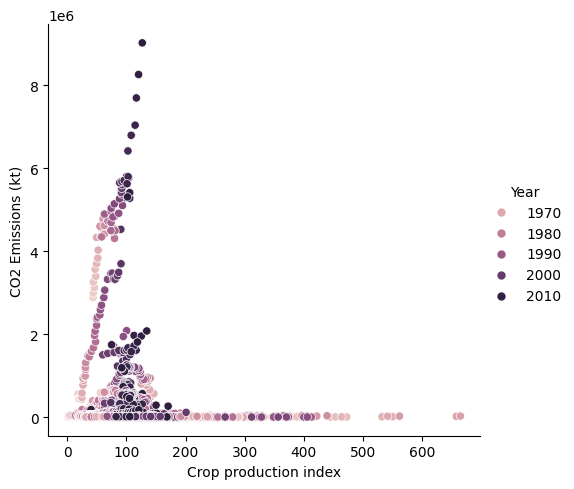

In [ ]:
sns.relplot(x="Crop production index", y="CO2 Emissions (kt)", hue="Year", data=df)

Relationship between CO2 emissions and crop production index for various countries over time showing how each country’s CO2 emissions and crop production index evolve, with larger countries having larger points (based on population).

Index(['CountryName', 'CountryCode', 'Year', 'Arable Land (% of land)',
       'CO2 Emissions (kt)', 'Crop production index', 'Food Production',
       'Crop Land (% of area)', 'Population growth (annual %)', 'Population',
       'Rural population (% of total)', 'Land area (sq. km)',
       'Urban population (% of total)', 'CO2 Emissions Category'],
      dtype='object', name='IndicatorName')
IndicatorName
CO2 Emissions (kt)       0
Crop production index    0
Population               0
Year                     0
CountryName              0
dtype: int64


Compare the Crop Land (% of area) with Population for all the countries within the dataset

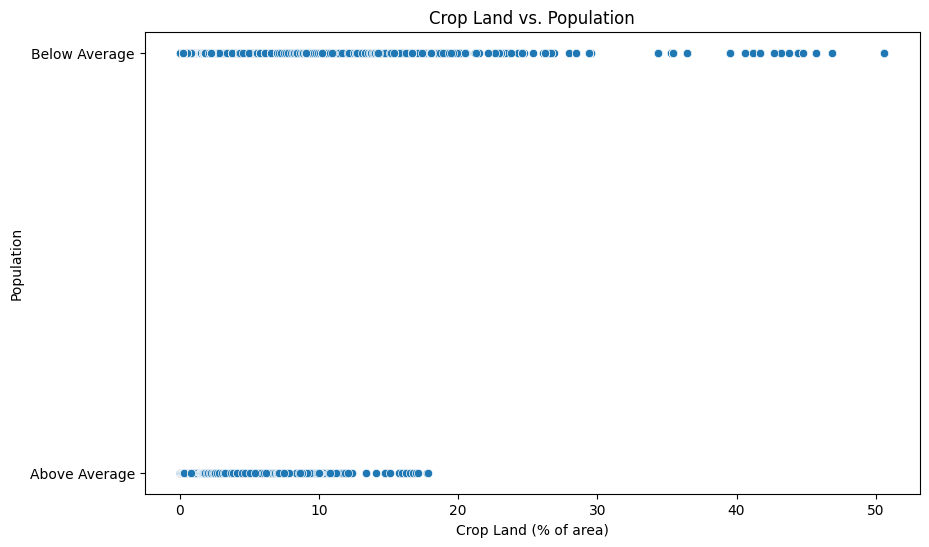

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Crop Land (% of area)', y='Population', data=df)
plt.title('Crop Land vs. Population')
plt.xlabel('Crop Land (% of area)')
plt.ylabel('Population')
plt.show()


# Urban Population

Visual how Urban population (% of total) is impacted by Land area.

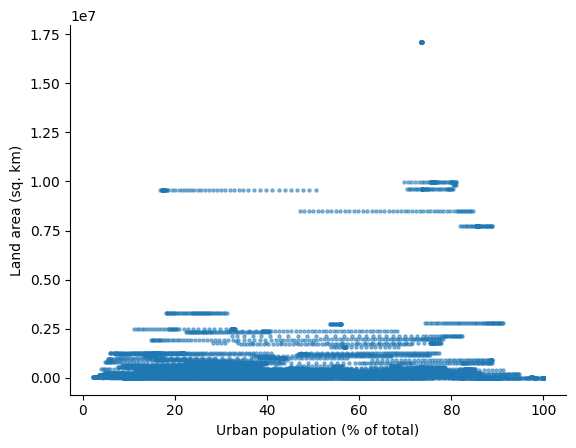

In [ ]:
from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Urban population (% of total)', y='Land area (sq. km)',  s=5, alpha=.5)
plt.gca().spines[['top', 'right',]].set_visible(False)


### 3 scatterplots containing 3 variables each...
1. CO2 Emissions (kt) in corrolation to Population growth (annual %) over the Years
2. Crop Land (% of area) in corrolation to Population growth (annual %) over the Years
3. Urban population (% of total) in corrolation to Population growth (annual %) over the Years

To show how Population growth (annual %) is impacted by these variables

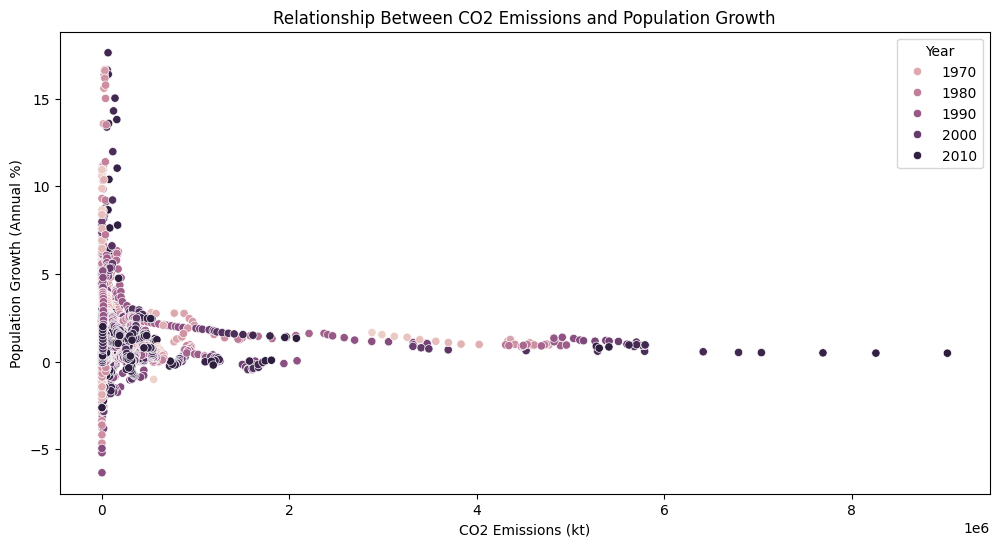

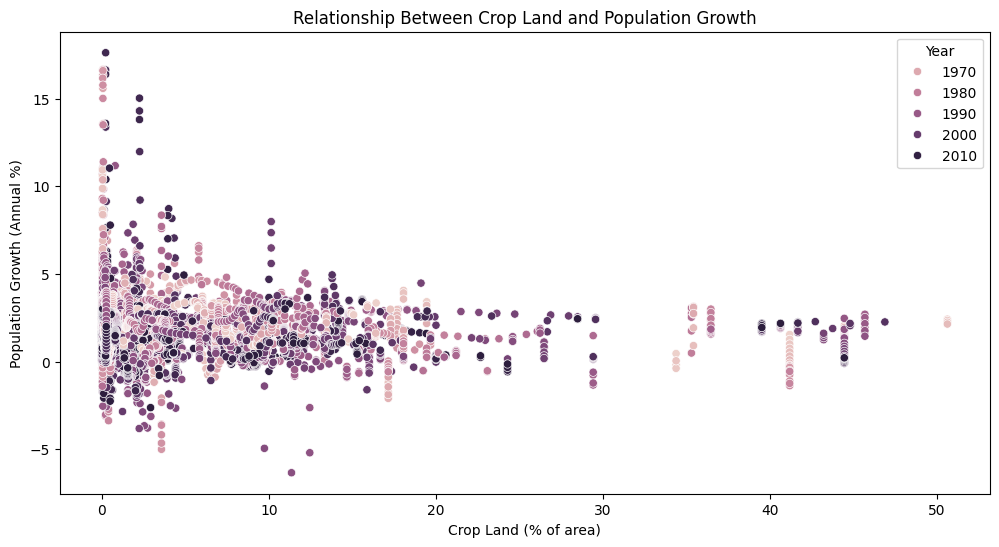

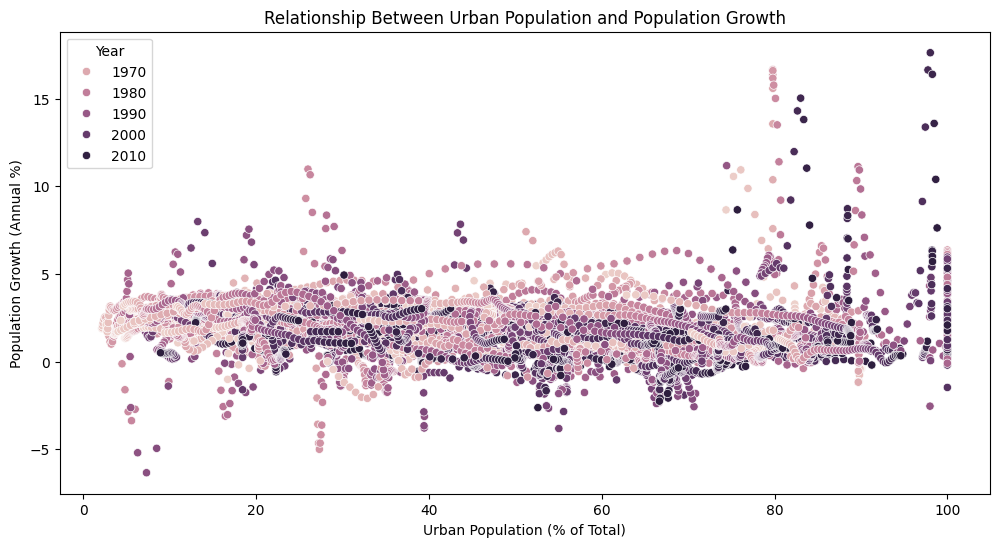

In [ ]:
df_filtered1 = df[df['CountryName'] == 1961]

plt.figure(figsize=(12, 6))
sns.scatterplot(x='CO2 Emissions (kt)', y='Population growth (annual %)', hue='Year',data=df)
plt.title('Relationship Between CO2 Emissions and Population Growth')
plt.xlabel('CO2 Emissions (kt)')
plt.ylabel('Population Growth (Annual %)')
plt.show()


plt.figure(figsize=(12, 6))
sns.scatterplot(x='Crop Land (% of area)', y='Population growth (annual %)',hue='Year', data=df)
plt.title('Relationship Between Crop Land and Population Growth')
plt.xlabel('Crop Land (% of area)')
plt.ylabel('Population Growth (Annual %)')
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Urban population (% of total)', y='Population growth (annual %)',hue='Year', data=df)
plt.title('Relationship Between Urban Population and Population Growth')
plt.xlabel('Urban Population (% of Total)')
plt.ylabel('Population Growth (Annual %)')
plt.show()

### Holistic Array of Scatterplots

Compare the CO2 Emissions (kt), Population growth (annual %), Crop Land (% of area), and Population for all the countries within the dataset as cross plots for 2 vairables in a spread of scatterplots

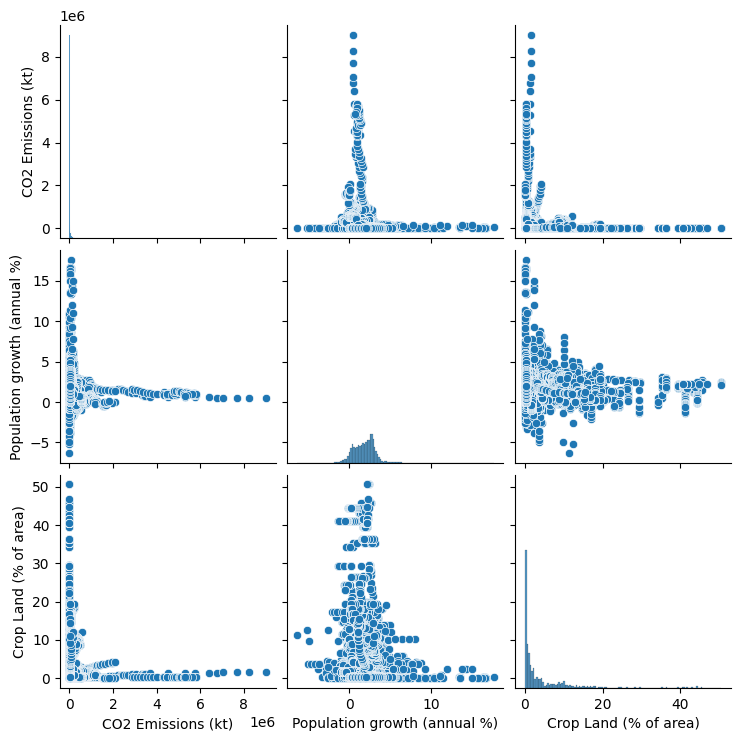

In [ ]:
sns.pairplot(df[['CO2 Emissions (kt)', 'Population growth (annual %)', 'Crop Land (% of area)', 'Population']])
plt.show()

# Map Visualizations

In [ ]:
!pip install folium
import folium

In [ ]:
url = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data'
state_geo = f'{url}/us-states.json' # for US map with state boundaries
world_geo = f'{url}/world-countries.json' # for world map with country boundaries


Map visualization regarding the Crop production index of the world

In [ ]:
import plotly.express as px
fig = px.choropleth(
    df,
    geojson=world_geo,
    locations='CountryCode',
    color='Rural population (% of total)',
    color_continuous_scale="Viridis",
    range_color=(df['Rural population (% of total)'].min(), df['Rural population (% of total)'].max()),
    labels={"Rural population (% of total population)"}
)

fig.show()

Map visualization regarding the Urban population (% of total) of the world


In [ ]:
map2 = folium.Map(location=[40, 0], zoom_start=0.5) # [40, 0]: Lattitue, Longitue coordinates of map-center.
filtered_df = df[df['Year'] == 2010]
folium.Choropleth(geo_data=world_geo,
                  data=filtered_df,
             name='choropleth',
             columns=['CountryCode', 'Urban population (% of total)'],
             key_on='feature.id',
             fill_color='YlGnBu', fill_opacity=0.7, line_opacity=0.2,
             legend_name='Urban population (% of total)').add_to(map2)
folium.LayerControl().add_to(map2)
map2